In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [3]:
total_leads = len(df)

contacted = len(df[df["contact"] != "unknown"])

converted = len(df[df["y"] == "yes"])

print("Total Leads:", total_leads)
print("Contacted:", contacted)
print("Converted:", converted)

Total Leads: 45211
Contacted: 32191
Converted: 5289


In [4]:
lead_to_contact = contacted / total_leads * 100
contact_to_conversion = converted / contacted * 100
overall_conversion = converted / total_leads * 100

print("Lead to Contact Rate:", round(lead_to_contact, 2), "%")
print("Contact to Conversion Rate:", round(contact_to_conversion, 2), "%")
print("Overall Conversion Rate:", round(overall_conversion, 2), "%")

Lead to Contact Rate: 71.2 %
Contact to Conversion Rate: 16.43 %
Overall Conversion Rate: 11.7 %


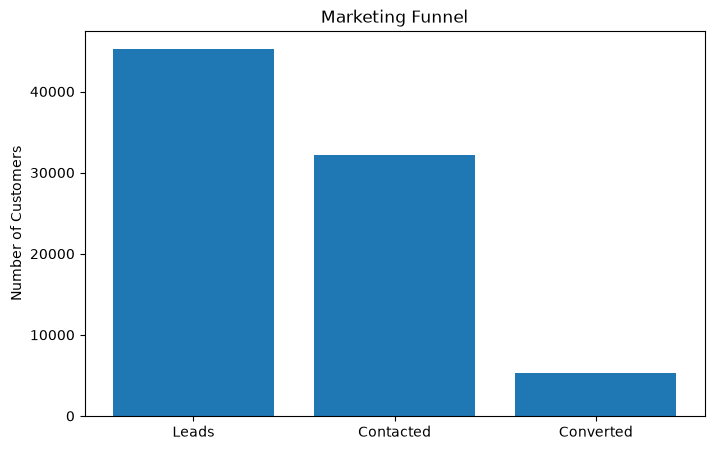

In [5]:
stages = ["Leads", "Contacted", "Converted"]
values = [total_leads, contacted, converted]

plt.figure(figsize=(8,5))
plt.bar(stages, values)
plt.title("Marketing Funnel")
plt.ylabel("Number of Customers")
plt.show()

In [6]:
channel_analysis = df.groupby("contact")["y"].apply(
    lambda x: (x == "yes").mean() * 100
).sort_values(ascending=False)

print(channel_analysis)

contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: y, dtype: float64


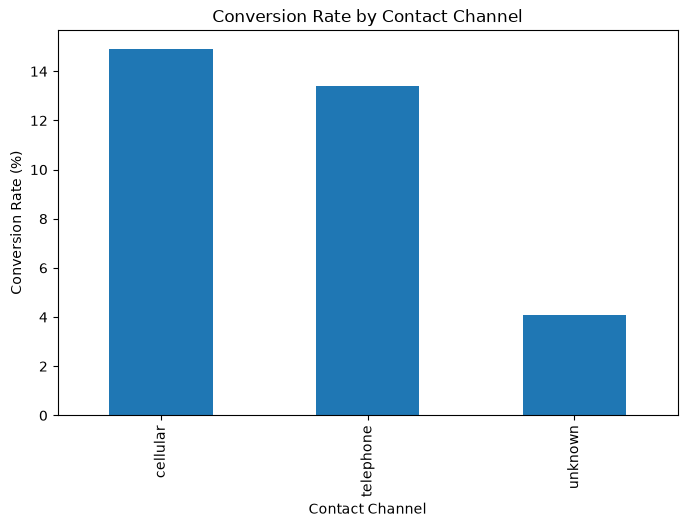

In [7]:
channel_analysis.plot(kind="bar", figsize=(8,5))
plt.title("Conversion Rate by Contact Channel")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Contact Channel")
plt.show()

In [8]:
campaign_analysis = df.groupby("campaign")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

campaign_analysis.head(10)

campaign
1     14.597583
2     11.203519
3     11.193624
4      9.000568
5      7.879819
6      7.126259
7      6.394558
8      5.925926
9      6.422018
10     5.263158
Name: y, dtype: float64

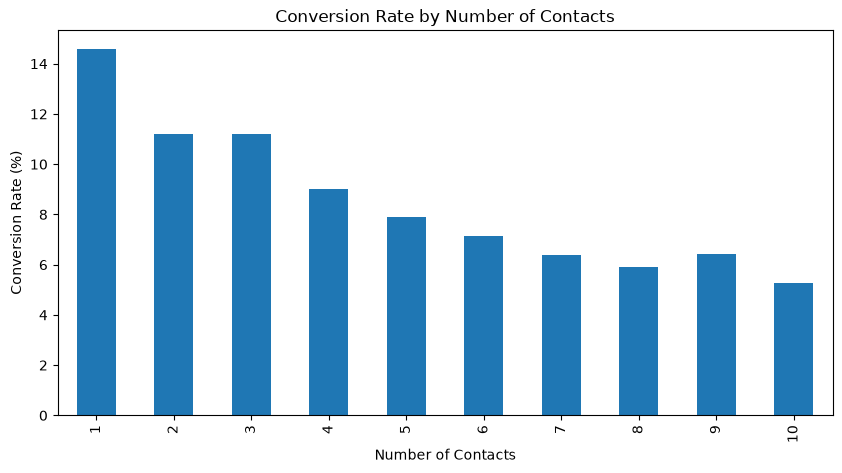

In [9]:
campaign_analysis.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Conversion Rate by Number of Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Conversion Rate (%)")
plt.show()

## Funnel Drop-off Analysis

The funnel shows the movement from total leads to contacted customers and finally to converted customers. The largest drop-off occurs before conversion, indicating that improving customer engagement and targeting can increase overall conversion performance.

## Recommendations

- Focus marketing efforts on channels with higher conversion rates.
- Improve targeting to reduce ineffective customer contacts.
- Prioritize customer segments with stronger conversion performance.
- Reduce excessive contact attempts that produce low conversion.
- Improve customer engagement strategies to increase lead-to-customer conversion.